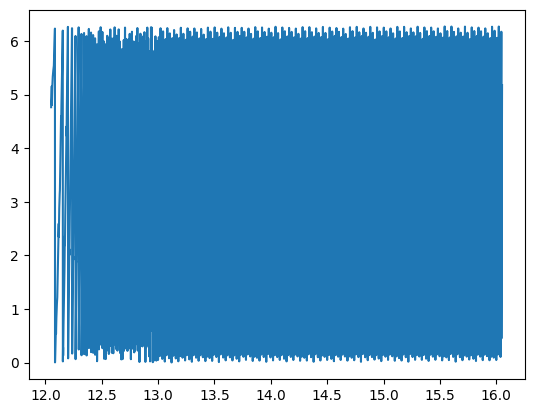

In [28]:
# In this module I'm messing around with a very naive speed estimator using the derivative of position.
# I read in AN2590 that after the Luenberger observer has a position estimate, a heavily filtered derivative
# can be used to get the speed. I tried out a simple approach on HW and actually saw something promising,
# though it was extremely noisy. Since the position is just a sawtooth wave, I can re-create that here and
# mess around with the parameters without running the HW.

import numpy as np
import matplotlib.pyplot as plt

# Import the sawtooth wave from actual system observer measurments
observer_data = np.loadtxt("system_observer_monitor.csv", delimiter=",", skiprows=1)
t = observer_data[:, 0] * 1e-6
est_pos = observer_data[:, 1]
est_omega = observer_data[:, 2]

# Parameters for the sampling of the observer system
sample_freq = 5000  # Hardware sample rate
nyq_rate = sample_freq / 2.0  # Nyquist rate

# Plot the position data
plt.plot(t, est_pos)
plt.show()

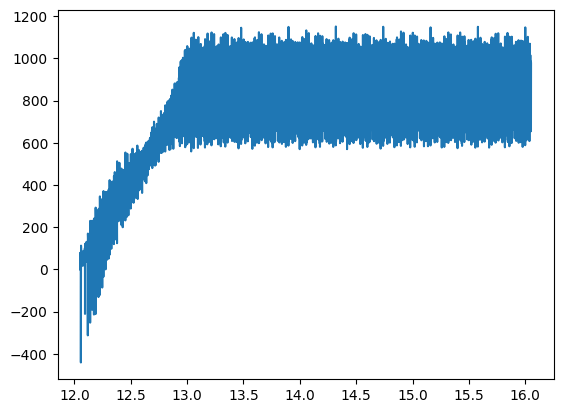

In [29]:
# Compute the derivative of the sawtooth wave
dPos = np.zeros(len(est_pos))
for i in range(1, len(est_pos)):
    dt = t[i] - t[i - 1]
    dtheta = est_pos[i] - est_pos[i - 1]

    # Wrap the derivative to the range -pi to pi to help with numerical issues
    while dtheta > np.pi:
        dtheta -= 2 * np.pi
    while dtheta < -np.pi:
        dtheta += 2 * np.pi

    dPos[i] = dtheta / dt

# Plot the derivative of the sawtooth wave
plt.plot(t, dPos)
plt.show()

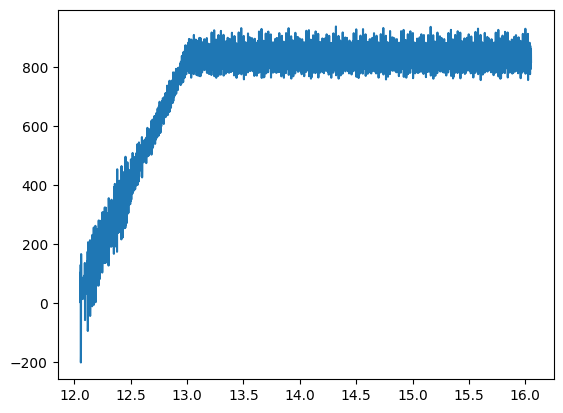

In [30]:
# Add an FIR filter to process the raw output of the derivative
from scipy.signal import kaiserord, firwin

# Define the filter specifications
width = 500.0 / nyq_rate  # Transition band width in Hz
ripple_db = 60   # Stopband attenuation in dB
cutoff_hz = 1500  # Cutoff frequency in Hz

# Design the FIR filter
N, beta = kaiserord(ripple_db, width)
taps = firwin(N, cutoff_hz / nyq_rate, window=('kaiser', beta))

# Plot the filtered derivative of the sawtooth wave
fir_filtered_dPos = np.convolve(dPos, taps, mode='same')
plt.plot(t, fir_filtered_dPos)
plt.show()


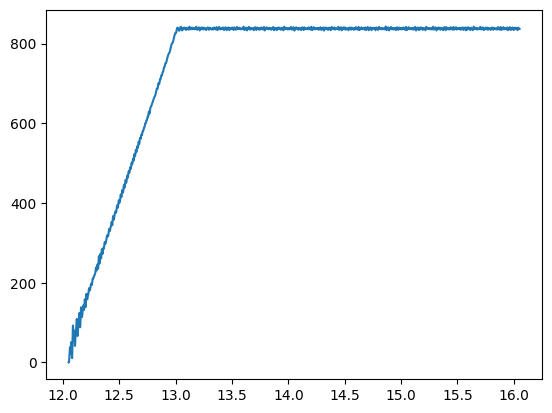

In [31]:
# Add three stages of an IIR filter to process the FIR output
from scipy import signal

# Define the filter specifications
pass_freq = 300   # Pass band frequency
transition_freq = 150  # Transition band frequency
stop_freq = pass_freq + transition_freq     # Stop band frequency
passband_ripple = 0.1  # Passband ripple in dB
stopband_atten = 60    # Stopband attenuation in dB

# Design the IIR filter
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html
system = signal.iirdesign(wp=pass_freq, ws=stop_freq, gpass=passband_ripple, gstop=stopband_atten,
                          analog=False, ftype='cheby2', output='sos', fs=sample_freq)

# Plot the filtered derivative of the sawtooth wave
iir_stage1_output = signal.sosfilt(system, fir_filtered_dPos)
# iir_stage2_output = signal.sosfilt(system, iir_stage1_output)
# iir_stage3_output = signal.sosfilt(system, iir_stage2_output)

plt.plot(t, iir_stage1_output)
plt.show()
